In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.tri as tri
import math
from scipy.special import kv 
from scipy.special import kve
from scipy import integrate
from joblib import Parallel, delayed
from scipy.integrate import quad
from numba import njit, prange
from scipy.interpolate import RegularGridInterpolator
from scipy.integrate import dblquad
from scipy.interpolate import CubicSpline

In [2]:
DTT = open('MVe Dipole table.txt','r')
with open("MVe Dipole table.txt", "r") as file:
    lines = file.readlines()
print(lines)

['     Y            r             N(r,Y) \n', '0.0000000000000000 0.0000010000000000 0.0000000000002286\n', '0.0000000000000000 0.0000010472494123 0.0000000000002499\n', '0.0000000000000000 0.0000010967313316 0.0000000000002733\n', '0.0000000000000000 0.0000011485512424 0.0000000000002988\n', '0.0000000000000000 0.0000012028196136 0.0000000000003267\n', '0.0000000000000000 0.0000012596521335 0.0000000000003572\n', '0.0000000000000000 0.0000013191699565 0.0000000000003905\n', '0.0000000000000000 0.0000013814999616 0.0000000000004270\n', '0.0000000000000000 0.0000014467750229 0.0000000000004669\n', '0.0000000000000000 0.0000015151342925 0.0000000000005104\n', '0.0000000000000000 0.0000015867234973 0.0000000000005581\n', '0.0000000000000000 0.0000016616952501 0.0000000000006101\n', '0.0000000000000000 0.0000017402093741 0.0000000000006670\n', '0.0000000000000000 0.0000018224332443 0.0000000000007293\n', '0.0000000000000000 0.0000019085421440 0.0000000000007973\n', '0.0000000000000000 0.00

In [3]:
MVA = open('redx-2009-parsed-small-x(2).txt','r')
with open("redx-2009-parsed-small-x(2).txt", "r") as file:
    linesR = file.readlines()
print(linesR)

['roots [GeV]    Q2 [GeV2]                  x                  sigma_r         relative error sigma_r \n', '301.0000000000000000 0.0450000000000000 0.0000006210000000       0.0800000000000000             9.7674715254256057 \n', '301.0000000000000000 0.0650000000000000 0.0000008970000000       0.1110000000000000             8.0017748031296154 \n', '301.0000000000000000 0.0650000000000000 0.0000010200000000       0.1110000000000000             8.7284935699122794 \n', '301.0000000000000000 0.0850000000000000 0.0000011700000000       0.1360000000000000             7.3905547829645375 \n', '301.0000000000000000 0.0850000000000000 0.0000013400000000       0.1300000000000000             5.4943516450988099 \n', '301.0000000000000000 0.0850000000000000 0.0000015600000000       0.1260000000000000             6.8720375435528576 \n', '301.0000000000000000 0.1000000000000000 0.0000015100000000       0.1650000000000000             7.8332560279873400 \n', '301.0000000000000000 0.1000000000000000 0.000

In [4]:
DIPOLEdata = np.loadtxt('MVe Dipole table.txt', skiprows=1)

# Split into separate arrays
Y = DIPOLEdata[:, 0]
R = DIPOLEdata[:, 1]
N = DIPOLEdata[:, 2]

In [5]:
# Build Y_vals, R_vals_dip, N_grid as before
Y_vals = np.unique(Y)
R_vals_dip = np.unique(R)
# Build the 2D dipole amplitude grid N(Y, R)
NY = len(Y_vals)
NR = len(R_vals_dip)

N_grid = np.zeros((NY, NR))

for i in range(len(N)):
    iy = np.searchsorted(Y_vals, Y[i])
    ir = np.searchsorted(R_vals_dip, R[i])
    N_grid[iy, ir] = N[i]


# Convert Y -> x
x_vals = 0.01 * np.exp(-Y_vals)

# IMPORTANT: ensure x is increasing for searchsorted
if x_vals[0] > x_vals[-1]:
    x_vals = x_vals[::-1]
    N_grid = N_grid[::-1, :]

logx_vals = np.log(x_vals)

# Make contiguous (Numba requirement)
x_vals = np.ascontiguousarray(x_vals, dtype=np.float64)
logx_vals = np.ascontiguousarray(logx_vals, dtype=np.float64)
R_vals_dip = np.ascontiguousarray(R_vals_dip, dtype=np.float64)
logR_vals_dip = np.ascontiguousarray(np.log(R_vals_dip), dtype=np.float64)
N_grid = np.ascontiguousarray(N_grid, dtype=np.float64)

In [6]:
# -------------------------------------------------
# Cubic splines in log(R) for each x-slice
# -------------------------------------------------
spline_coeffs = np.zeros(
    (len(logx_vals),
     len(logR_vals_dip)-1,
     4)
)

for ix in range(len(logx_vals)):
    cs = CubicSpline(
        logR_vals_dip,
        N_grid[ix, :],
        bc_type='natural'
    )

    spline_coeffs[ix] = cs.c.T

spline_coeffs = np.ascontiguousarray(
    spline_coeffs,
    dtype=np.float64
)

In [7]:
@njit(fastmath=True)
def spline_eval_R(logR, coeffs_row, logR_grid):

    if logR <= logR_grid[0]:
        ir = 0
    elif logR >= logR_grid[-1]:
        ir = len(logR_grid) - 2
    else:
        ir = np.searchsorted(logR_grid, logR) - 1

    dx = logR - logR_grid[ir]

    c0 = coeffs_row[ir,0]
    c1 = coeffs_row[ir,1]
    c2 = coeffs_row[ir,2]
    c3 = coeffs_row[ir,3]

    return ((c0*dx + c1)*dx + c2)*dx + c3

In [8]:
#----------------- Interpolation-----------------------------
@njit(fastmath=True)
def dipole_amplitude_x(x, R, logx_vals, logR_vals, N_grid, spline_coeffs):
    logx = np.log(x)
    logR = np.log(R)

    # ----------------------------
    # linear interpolation in log(x)
    # ----------------------------
    if logx <= logx_vals[0]:
        ix = 0
    elif logx >= logx_vals[-1]:
        ix = len(logx_vals) - 2
    else:
        ix = np.searchsorted(logx_vals, logx) - 1

    logx1 = logx_vals[ix]
    logx2 = logx_vals[ix + 1]

    tx = (logx - logx1)/(logx2 - logx1)

    N1 = spline_eval_R(
        logR,
        spline_coeffs[ix],
        logR_vals
    )

    N2 = spline_eval_R(
        logR,
        spline_coeffs[ix + 1],
        logR_vals
    )

    # linear interpolation in x
    return (1.0 - tx)*N1 + tx*N2

In [9]:
def dipole_amp_interp(x, r):
    return dipole_amplitude_x(
        x,
        r,
        logx_vals,
        logR_vals_dip,
        N_grid,
        spline_coeffs
    )

In [65]:
DISdata = np.loadtxt('redx-2009-parsed-small-x(2).txt', skiprows=1)

# Split into separate arrays
roots_DIS = DISdata[:,0]
s_DIS = roots_DIS**2
Q2_DIS= DISdata[:, 1]
x_DIS = DISdata[:, 2]
sigma_r_DIS = DISdata[:, 3]
rel_err_sigma_r_DIS = DISdata[:, 4]

lengthQ2_DIS = len(Q2_DIS)
lengthx_DIS = len(x_DIS)

In [102]:
PiRp2MV = (10.32) * 2.56819
ef2 = (2/3)**2 + (-1/3)**2 + (-1/3)**2
mf = 0.140
Alpha_em = 1 / 137
nc = 3
lamb =0.2853
x0 = 5.34e-4 
QS0 = 1

In [103]:
def GBWDipole(x, r):
    #xeff = x * ((Q2 + 4*mf**2)/Q2)
    Qs2 = QS0 * (x0/x)**lamb
    return 1.0 - np.exp(-0.25*r**2*Qs2)

In [68]:
#def y(x_vals, Q2_vals, s_val): 
#    return (Q2_vals)/(x_vals * s_val)

In [86]:
def photonWFSquared(z, r, Q2, pol):

    eps2 = z*(1-z)*Q2 + mf**2
    arg = np.sqrt(eps2)*r

    K0 = np.exp(-arg)*kve(0,arg)
    K1 = np.exp(-arg)*kve(1,arg)

    coeff = 2*nc*Alpha_em*ef2/(4*np.pi**2)

    if pol == 0:

        return (
            coeff
            * 4*Q2*z**2*(1-z)**2
            * K0**2
        )

    if pol == 1:

        return (
            coeff
            * (
                (z**2+(1-z)**2)
                * eps2
                * K1**2
                +
                mf**2*K0**2
            )
        )

In [104]:
def SigmaLDP_dblquad(x_val, Q2_val):

    def integrand(u, z):

        r = np.exp(u)
        
        
        Nval = GBWDipole(x_val, r)

        return (
            r
            * photonWFSquared(z, r, Q2_val, 0)
            * Nval
            * r
        )

    val, err = dblquad(
        integrand,
        0.0,
        0.5,
        lambda z: np.log(1e-6),
        lambda z: np.log(100.0),
        epsabs=1e-6,
        epsrel=1e-1
    )

    return 8*np.pi*PiRp2MV*val 

In [105]:
def SigmaTDP_dblquad(x_val, Q2_val):

    def integrand(u, z):

        # transform variable
        r = np.exp(u)

        Nval = GBWDipole(x_val, r)

        return (
            r
            * photonWFSquared(z, r, Q2_val, 1)
            * Nval
            * r          # Jacobian dr = r du
        )

    val, err = dblquad(
        integrand,
        0.0,
        0.5,
        lambda z: np.log(1e-6),
        lambda z: np.log(100.0),
        epsabs=1e-6,
        epsrel=1e-1
    )

    return 8*np.pi*PiRp2MV*val 

In [89]:
def FLDP(x,Q2):

    sigmaL = SigmaLDP_dblquad(x,Q2)

    return (
        Q2
        /(4*np.pi**2*Alpha_em)
        * sigmaL
    )

def F2DP(x,Q2):

    sigmaL = SigmaLDP_dblquad(x,Q2)
    sigmaT = SigmaTDP_dblquad(x,Q2)

    return (
        Q2
        /(4*np.pi**2*Alpha_em)
        *(sigmaL+sigmaT)
    )

def SigmaRDP(x,Q2,s):

    sigmaL = SigmaLDP_dblquad(x,Q2)
    sigmaT = SigmaTDP_dblquad(x,Q2)

    yval = Q2/(x*s)
    #yval = x * ((Q2 + 4 * mf**2) / Q2)

    return (
        Q2/(4*np.pi**2*Alpha_em)
        *(
            sigmaT
            +
            (2*(1-yval))
            /(1+(1-yval)**2)
            *sigmaL
        )
    )

def compute_SigmaRDP_points():

    SigmaR_data = np.zeros(len(x_DIS))

    for i in range(len(x_DIS)):

        SigmaR_data[i] = SigmaRDP(
            x_DIS[i],
            Q2_DIS[i],
            s_DIS[i]
        )

        #print(i+1, "/", len(x_DIS))

    return SigmaR_data

In [90]:
def compute_FL_grid():

    FL_data = np.zeros((len(Q2_DIS), len(x_DIS)))

    for i, Q2_val in enumerate(Q2_DIS):

        results = Parallel(n_jobs=-1)(
            delayed(FLDP)(
                x_val,
                Q2_val
            )
            for x_val in x_DIS
            )

        FL_data[i,:] = results

    return FL_data
FLgrid = compute_FL_grid()

def compute_F2_grid():

    F2_data = np.zeros((len(Q2_DIS), len(x_DIS)))

    for i, Q2_val in enumerate(Q2_DIS):

        results = Parallel(n_jobs=-1)(
            delayed(F2DP)(
                x_val,
                Q2_val
            )
            for x_val in x_DIS
        )

        F2_data[i,:] = results

    return F2_data
F2grid = compute_F2_grid()

def compute_SigmaR_grid():

    SigmaR_data = np.zeros((len(Q2_DIS), len(x_DIS)))

    for i, Q2_val in enumerate(Q2_DIS):

        s_val = s_DIS[i]

        results = Parallel(n_jobs=-1)(
            delayed(SigmaRDP)(
                x_val,
                Q2_val,
                s_val
            )
            for x_val in x_DIS
        )

        SigmaR_data[i,:] = results

    return SigmaR_data

Q² = 8.5000 GeV²


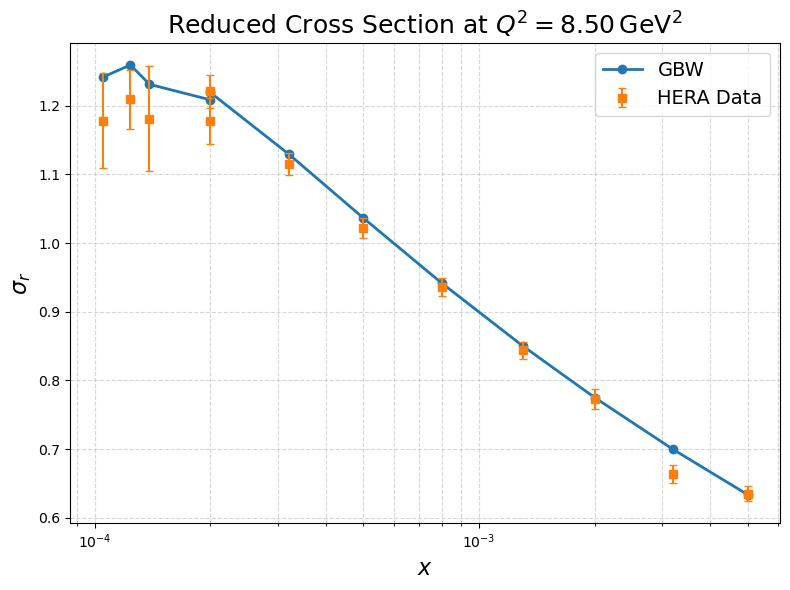

In [91]:
# ----------------------------------------------------------
# Fixed Q² Reduced Cross Section Plot
# Using physical HERA x-values only
# ----------------------------------------------------------

# Desired Q²
Q2_fixed = 8.5 

# ----------------------------------------------------------
# Find nearest available experimental Q²
# ----------------------------------------------------------

Q2_unique = np.unique(Q2_DIS)

Q2_selected = Q2_unique[
    np.argmin(np.abs(Q2_unique - Q2_fixed))
]
print(f"Q² = {Q2_selected:.4f} GeV²")

# ----------------------------------------------------------
# Select only points with this Q²
# ----------------------------------------------------------

mask = Q2_DIS == Q2_selected

x_selected = x_DIS[mask]
s_selected = s_DIS[mask]

sigma_exp = sigma_r_DIS[mask]

# ----------------------------------------------------------
# Experimental uncertainties
# ----------------------------------------------------------

abs_err = sigma_r_DIS * rel_err_sigma_r_DIS / 100
sigma_err = abs_err[mask]

# ----------------------------------------------------------
# Compute theory curve
# ----------------------------------------------------------

SigmaR_curve = np.zeros(len(x_selected))

for i in range(len(x_selected)):

    SigmaR_curve[i] = SigmaRDP(
        x_selected[i],
        Q2_selected,
        s_selected[i]
    )

# ----------------------------------------------------------
# Sort for plotting
# ----------------------------------------------------------

sort_idx = np.argsort(x_selected)

x_plot = x_selected[sort_idx]
sigma_plot = SigmaR_curve[sort_idx]
sigma_exp_plot = sigma_exp[sort_idx]
sigma_err_plot = sigma_err[sort_idx]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Theory
plt.plot(
    x_plot,
    sigma_plot,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='GBW'
)

# Data with error bars
plt.errorbar(
    x_plot,
    sigma_exp_plot,
    yerr=sigma_err_plot,
    fmt='s',
    markersize=6,
    capsize=3,
    label='HERA Data'
)

plt.xscale('log')

plt.xlabel(r'$x$', fontsize=16)
plt.ylabel(r'$\sigma_r$', fontsize=16)

plt.title(
    rf'Reduced Cross Section at $Q^2={Q2_selected:.2f}\,\mathrm{{GeV}}^2$', 
    fontsize=18
)

plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig("Fixed Q^2 Reduced cross section 8.5 GBW.pdf", format="pdf")
plt.show()

Q² = 1.5000 GeV²


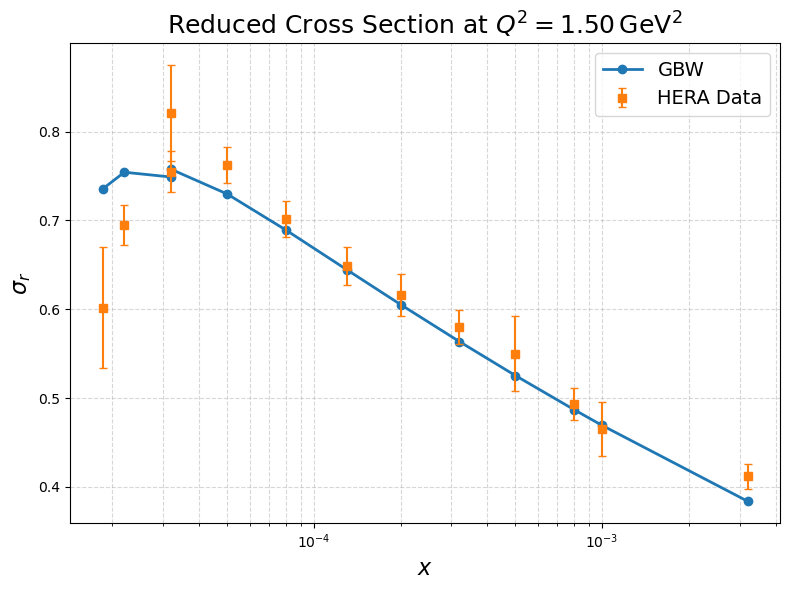

In [92]:
# ----------------------------------------------------------
# Fixed Q² Reduced Cross Section Plot
# Using physical HERA x-values only
# ----------------------------------------------------------

# Desired Q²
Q2_fixed = 1.5 

# ----------------------------------------------------------
# Find nearest available experimental Q²
# ----------------------------------------------------------

Q2_unique = np.unique(Q2_DIS)

Q2_selected = Q2_unique[
    np.argmin(np.abs(Q2_unique - Q2_fixed))
]
print(f"Q² = {Q2_selected:.4f} GeV²")

# ----------------------------------------------------------
# Select only points with this Q²
# ----------------------------------------------------------

mask = Q2_DIS == Q2_selected

x_selected = x_DIS[mask]
s_selected = s_DIS[mask]

sigma_exp = sigma_r_DIS[mask]

# ----------------------------------------------------------
# Experimental uncertainties
# ----------------------------------------------------------

abs_err = sigma_r_DIS * rel_err_sigma_r_DIS / 100
sigma_err = abs_err[mask]

# ----------------------------------------------------------
# Compute theory curve
# ----------------------------------------------------------

SigmaR_curve = np.zeros(len(x_selected))

for i in range(len(x_selected)):

    SigmaR_curve[i] = SigmaRDP(
        x_selected[i],
        Q2_selected,
        s_selected[i]
    )

# ----------------------------------------------------------
# Sort for plotting
# ----------------------------------------------------------

sort_idx = np.argsort(x_selected)

x_plot = x_selected[sort_idx]
sigma_plot = SigmaR_curve[sort_idx]
sigma_exp_plot = sigma_exp[sort_idx]
sigma_err_plot = sigma_err[sort_idx]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Theory
plt.plot(
    x_plot,
    sigma_plot,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='GBW'
)

# Data with error bars
plt.errorbar(
    x_plot,
    sigma_exp_plot,
    yerr=sigma_err_plot,
    fmt='s',
    markersize=6,
    capsize=3,
    label='HERA Data'
)

plt.xscale('log')

plt.xlabel(r'$x$', fontsize=16)
plt.ylabel(r'$\sigma_r$', fontsize=16)

plt.title(
    rf'Reduced Cross Section at $Q^2={Q2_selected:.2f}\,\mathrm{{GeV}}^2$', 
    fontsize=18
)

plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig("Fixed Q^2 Reduced cross section 1.5 GBW.pdf", format="pdf")
plt.show()

Q² = 27.0000 GeV²


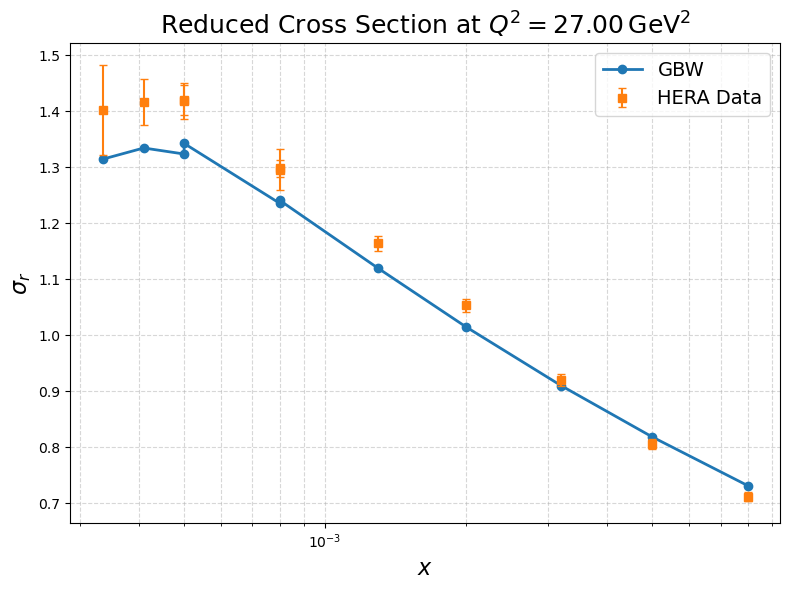

In [93]:
# ----------------------------------------------------------
# Fixed Q² Reduced Cross Section Plot
# Using physical HERA x-values only
# ----------------------------------------------------------

# Desired Q²
Q2_fixed = 27 

# ----------------------------------------------------------
# Find nearest available experimental Q²
# ----------------------------------------------------------

Q2_unique = np.unique(Q2_DIS)

Q2_selected = Q2_unique[
    np.argmin(np.abs(Q2_unique - Q2_fixed))
]
print(f"Q² = {Q2_selected:.4f} GeV²")

# ----------------------------------------------------------
# Select only points with this Q²
# ----------------------------------------------------------

mask = Q2_DIS == Q2_selected

x_selected = x_DIS[mask]
s_selected = s_DIS[mask]

sigma_exp = sigma_r_DIS[mask]

# ----------------------------------------------------------
# Experimental uncertainties
# ----------------------------------------------------------

abs_err = sigma_r_DIS * rel_err_sigma_r_DIS / 100
sigma_err = abs_err[mask]

# ----------------------------------------------------------
# Compute theory curve
# ----------------------------------------------------------

SigmaR_curve = np.zeros(len(x_selected))

for i in range(len(x_selected)):

    SigmaR_curve[i] = SigmaRDP(
        x_selected[i],
        Q2_selected,
        s_selected[i]
    )

# ----------------------------------------------------------
# Sort for plotting
# ----------------------------------------------------------

sort_idx = np.argsort(x_selected)

x_plot = x_selected[sort_idx]
sigma_plot = SigmaR_curve[sort_idx]
sigma_exp_plot = sigma_exp[sort_idx]
sigma_err_plot = sigma_err[sort_idx]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Theory
plt.plot(
    x_plot,
    sigma_plot,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='GBW'
)

# Data with error bars
plt.errorbar(
    x_plot,
    sigma_exp_plot,
    yerr=sigma_err_plot,
    fmt='s',
    markersize=6,
    capsize=3,
    label='HERA Data'
)

plt.xscale('log')

plt.xlabel(r'$x$', fontsize=16)
plt.ylabel(r'$\sigma_r$', fontsize=16)

plt.title(
    rf'Reduced Cross Section at $Q^2={Q2_selected:.2f}\,\mathrm{{GeV}}^2$', 
    fontsize=18
)

plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig("Fixed Q^2 Reduced cross section 27 GBW.pdf", format="pdf")
plt.show()

Q² = 0.5000 GeV²


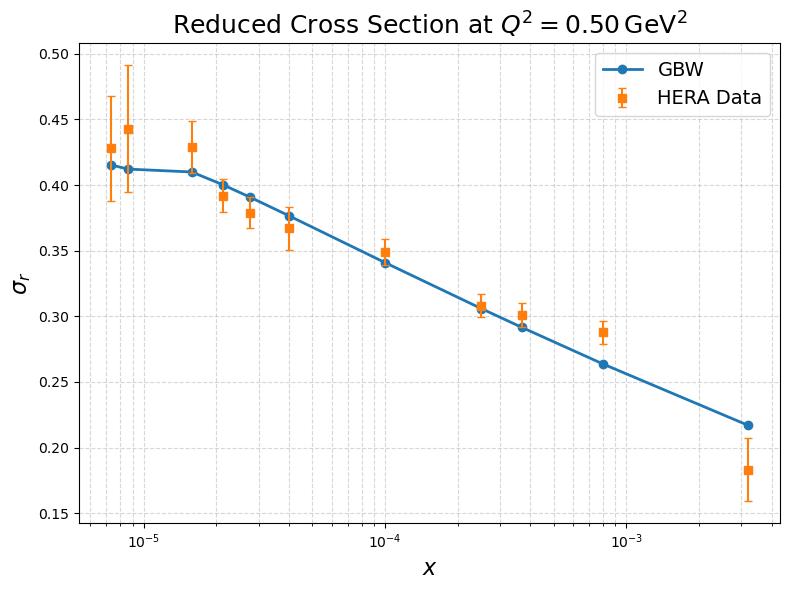

In [94]:
# ----------------------------------------------------------
# Fixed Q² Reduced Cross Section Plot
# Using physical HERA x-values only
# ----------------------------------------------------------

# Desired Q²
Q2_fixed = 0.5 

# ----------------------------------------------------------
# Find nearest available experimental Q²
# ----------------------------------------------------------

Q2_unique = np.unique(Q2_DIS)

Q2_selected = Q2_unique[
    np.argmin(np.abs(Q2_unique - Q2_fixed))
]
print(f"Q² = {Q2_selected:.4f} GeV²")

# ----------------------------------------------------------
# Select only points with this Q²
# ----------------------------------------------------------

mask = Q2_DIS == Q2_selected

x_selected = x_DIS[mask]
s_selected = s_DIS[mask]

sigma_exp = sigma_r_DIS[mask]

# ----------------------------------------------------------
# Experimental uncertainties
# ----------------------------------------------------------

abs_err = sigma_r_DIS * rel_err_sigma_r_DIS / 100
sigma_err = abs_err[mask]

# ----------------------------------------------------------
# Compute theory curve
# ----------------------------------------------------------

SigmaR_curve = np.zeros(len(x_selected))

for i in range(len(x_selected)):

    SigmaR_curve[i] = SigmaRDP(
        x_selected[i],
        Q2_selected,
        s_selected[i]
    )

# ----------------------------------------------------------
# Sort for plotting
# ----------------------------------------------------------

sort_idx = np.argsort(x_selected)

x_plot = x_selected[sort_idx]
sigma_plot = SigmaR_curve[sort_idx]
sigma_exp_plot = sigma_exp[sort_idx]
sigma_err_plot = sigma_err[sort_idx]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Theory
plt.plot(
    x_plot,
    sigma_plot,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='GBW'
)

# Data with error bars
plt.errorbar(
    x_plot,
    sigma_exp_plot,
    yerr=sigma_err_plot,
    fmt='s',
    markersize=6,
    capsize=3,
    label='HERA Data'
)

plt.xscale('log')

plt.xlabel(r'$x$', fontsize=16)
plt.ylabel(r'$\sigma_r$', fontsize=16)

plt.title(
    rf'Reduced Cross Section at $Q^2={Q2_selected:.2f}\,\mathrm{{GeV}}^2$', 
    fontsize=18
)

plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

Q² = 1.2000 GeV²


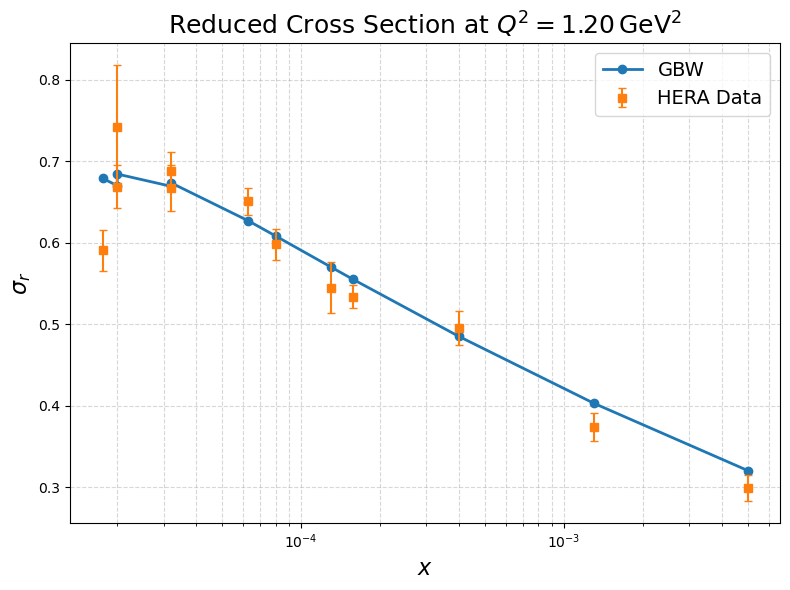

In [95]:
# ----------------------------------------------------------
# Fixed Q² Reduced Cross Section Plot
# Using physical HERA x-values only
# ----------------------------------------------------------

# Desired Q²
Q2_fixed = 1.2 

# ----------------------------------------------------------
# Find nearest available experimental Q²
# ----------------------------------------------------------

Q2_unique = np.unique(Q2_DIS)

Q2_selected = Q2_unique[
    np.argmin(np.abs(Q2_unique - Q2_fixed))
]
print(f"Q² = {Q2_selected:.4f} GeV²")

# ----------------------------------------------------------
# Select only points with this Q²
# ----------------------------------------------------------

mask = Q2_DIS == Q2_selected

x_selected = x_DIS[mask]
s_selected = s_DIS[mask]

sigma_exp = sigma_r_DIS[mask]

# ----------------------------------------------------------
# Experimental uncertainties
# ----------------------------------------------------------

abs_err = sigma_r_DIS * rel_err_sigma_r_DIS / 100
sigma_err = abs_err[mask]

# ----------------------------------------------------------
# Compute theory curve
# ----------------------------------------------------------

SigmaR_curve = np.zeros(len(x_selected))

for i in range(len(x_selected)):

    SigmaR_curve[i] = SigmaRDP(
        x_selected[i],
        Q2_selected,
        s_selected[i]
    )

# ----------------------------------------------------------
# Sort for plotting
# ----------------------------------------------------------

sort_idx = np.argsort(x_selected)

x_plot = x_selected[sort_idx]
sigma_plot = SigmaR_curve[sort_idx]
sigma_exp_plot = sigma_exp[sort_idx]
sigma_err_plot = sigma_err[sort_idx]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Theory
plt.plot(
    x_plot,
    sigma_plot,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='GBW'
)

# Data with error bars
plt.errorbar(
    x_plot,
    sigma_exp_plot,
    yerr=sigma_err_plot,
    fmt='s',
    markersize=6,
    capsize=3,
    label='HERA Data'
)

plt.xscale('log')

plt.xlabel(r'$x$', fontsize=16)
plt.ylabel(r'$\sigma_r$', fontsize=16)

plt.title(
    rf'Reduced Cross Section at $Q^2={Q2_selected:.2f}\,\mathrm{{GeV}}^2$', 
    fontsize=18
)

plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(fontsize=14)

plt.savefig("Fixed Q^2 Reduced cross section 1.2 GBW.pdf", format="pdf")
plt.tight_layout()
plt.show()

Q² = 2.0000 GeV²


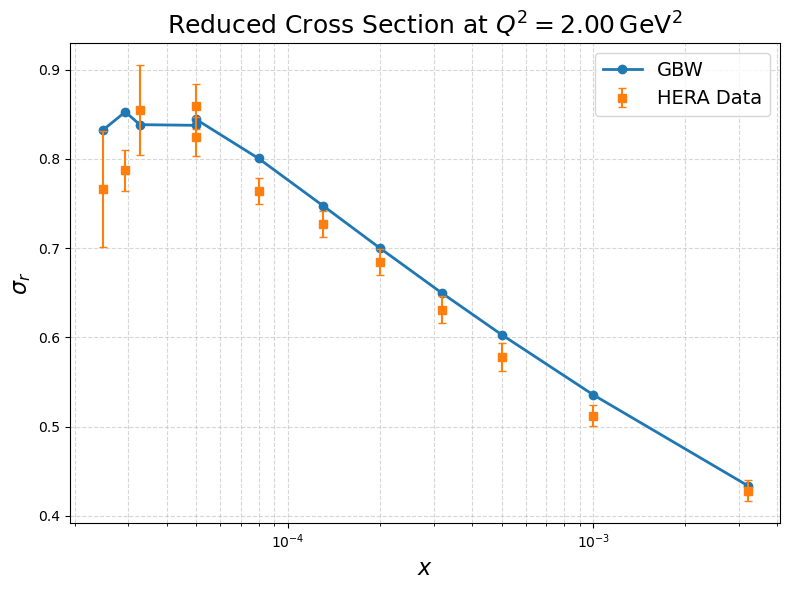

In [96]:
# ----------------------------------------------------------
# Fixed Q² Reduced Cross Section Plot
# Using physical HERA x-values only
# ----------------------------------------------------------

# Desired Q²
Q2_fixed = 2 

# ----------------------------------------------------------
# Find nearest available experimental Q²
# ----------------------------------------------------------

Q2_unique = np.unique(Q2_DIS)

Q2_selected = Q2_unique[
    np.argmin(np.abs(Q2_unique - Q2_fixed))
]
print(f"Q² = {Q2_selected:.4f} GeV²")

# ----------------------------------------------------------
# Select only points with this Q²
# ----------------------------------------------------------

mask = Q2_DIS == Q2_selected

x_selected = x_DIS[mask]
s_selected = s_DIS[mask]

sigma_exp = sigma_r_DIS[mask]

# ----------------------------------------------------------
# Experimental uncertainties
# ----------------------------------------------------------

abs_err = sigma_r_DIS * rel_err_sigma_r_DIS / 100
sigma_err = abs_err[mask]

# ----------------------------------------------------------
# Compute theory curve
# ----------------------------------------------------------

SigmaR_curve = np.zeros(len(x_selected))

for i in range(len(x_selected)):

    SigmaR_curve[i] = SigmaRDP(
        x_selected[i],
        Q2_selected,
        s_selected[i]
    )

# ----------------------------------------------------------
# Sort for plotting
# ----------------------------------------------------------

sort_idx = np.argsort(x_selected)

x_plot = x_selected[sort_idx]
sigma_plot = SigmaR_curve[sort_idx]
sigma_exp_plot = sigma_exp[sort_idx]
sigma_err_plot = sigma_err[sort_idx]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Theory
plt.plot(
    x_plot,
    sigma_plot,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='GBW'
)

# Data with error bars
plt.errorbar(
    x_plot,
    sigma_exp_plot,
    yerr=sigma_err_plot,
    fmt='s',
    markersize=6,
    capsize=3,
    label='HERA Data'
)

plt.xscale('log')

plt.xlabel(r'$x$', fontsize=16)
plt.ylabel(r'$\sigma_r$', fontsize=16)

plt.title(
    rf'Reduced Cross Section at $Q^2={Q2_selected:.2f}\,\mathrm{{GeV}}^2$', 
    fontsize=18
)

plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(fontsize=14)
plt.savefig("Fixed Q^2 Reduced cross section 2 GBW.pdf", format="pdf")
plt.tight_layout()
plt.show()

Q² = 0.1000 GeV²


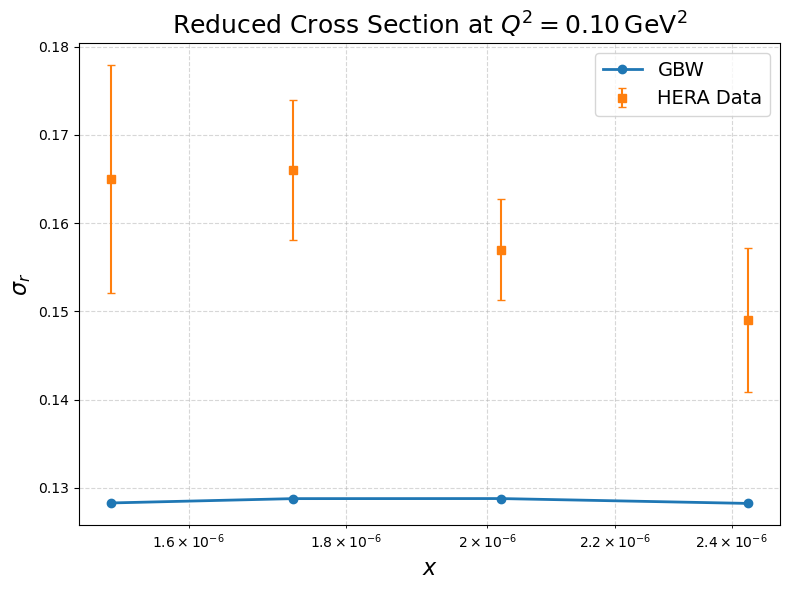

In [97]:
# ----------------------------------------------------------
# Fixed Q² Reduced Cross Section Plot
# Using physical HERA x-values only
# ----------------------------------------------------------

# Desired Q²
Q2_fixed = 0.1

# ----------------------------------------------------------
# Find nearest available experimental Q²
# ----------------------------------------------------------

Q2_unique = np.unique(Q2_DIS)

Q2_selected = Q2_unique[
    np.argmin(np.abs(Q2_unique - Q2_fixed))
]
print(f"Q² = {Q2_selected:.4f} GeV²")

# ----------------------------------------------------------
# Select only points with this Q²
# ----------------------------------------------------------

mask = Q2_DIS == Q2_selected

x_selected = x_DIS[mask]
s_selected = s_DIS[mask]

sigma_exp = sigma_r_DIS[mask]

# ----------------------------------------------------------
# Experimental uncertainties
# ----------------------------------------------------------

abs_err = sigma_r_DIS * rel_err_sigma_r_DIS / 100
sigma_err = abs_err[mask]

# ----------------------------------------------------------
# Compute theory curve
# ----------------------------------------------------------

SigmaR_curve = np.zeros(len(x_selected))

for i in range(len(x_selected)):

    SigmaR_curve[i] = SigmaRDP(
        x_selected[i],
        Q2_selected,
        s_selected[i]
    )

# ----------------------------------------------------------
# Sort for plotting
# ----------------------------------------------------------

sort_idx = np.argsort(x_selected)

x_plot = x_selected[sort_idx]
sigma_plot = SigmaR_curve[sort_idx]
sigma_exp_plot = sigma_exp[sort_idx]
sigma_err_plot = sigma_err[sort_idx]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Theory
plt.plot(
    x_plot,
    sigma_plot,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='GBW'
)

# Data with error bars
plt.errorbar(
    x_plot,
    sigma_exp_plot,
    yerr=sigma_err_plot,
    fmt='s',
    markersize=6,
    capsize=3,
    label='HERA Data'
)

plt.xscale('log')

plt.xlabel(r'$x$', fontsize=16)
plt.ylabel(r'$\sigma_r$', fontsize=16)

plt.title(
    rf'Reduced Cross Section at $Q^2={Q2_selected:.2f}\,\mathrm{{GeV}}^2$', 
    fontsize=18
)

plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig("Fixed Q^2 Reduced cross section 0.10 GBW.pdf", format="pdf")
plt.show()

Q² = 45.0000 GeV²


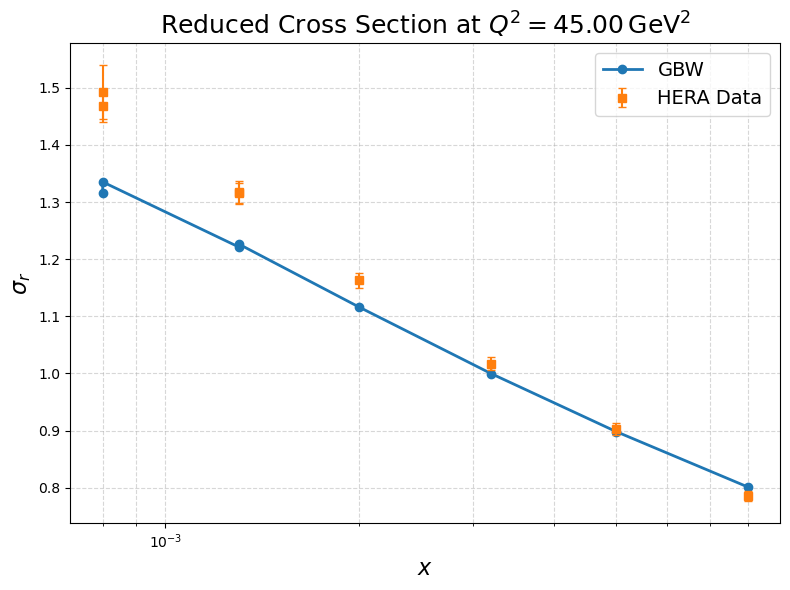

In [98]:
# ----------------------------------------------------------
# Fixed Q² Reduced Cross Section Plot
# Using physical HERA x-values only
# ----------------------------------------------------------

# Desired Q²
Q2_fixed = 45 

# ----------------------------------------------------------
# Find nearest available experimental Q²
# ----------------------------------------------------------

Q2_unique = np.unique(Q2_DIS)

Q2_selected = Q2_unique[
    np.argmin(np.abs(Q2_unique - Q2_fixed))
]
print(f"Q² = {Q2_selected:.4f} GeV²")

# ----------------------------------------------------------
# Select only points with this Q²
# ----------------------------------------------------------

mask = Q2_DIS == Q2_selected

x_selected = x_DIS[mask]
s_selected = s_DIS[mask]

sigma_exp = sigma_r_DIS[mask]

# ----------------------------------------------------------
# Experimental uncertainties
# ----------------------------------------------------------

abs_err = sigma_r_DIS * rel_err_sigma_r_DIS / 100
sigma_err = abs_err[mask]

# ----------------------------------------------------------
# Compute theory curve
# ----------------------------------------------------------

SigmaR_curve = np.zeros(len(x_selected))

for i in range(len(x_selected)):

    SigmaR_curve[i] = SigmaRDP(
        x_selected[i],
        Q2_selected,
        s_selected[i]
    )

# ----------------------------------------------------------
# Sort for plotting
# ----------------------------------------------------------

sort_idx = np.argsort(x_selected)

x_plot = x_selected[sort_idx]
sigma_plot = SigmaR_curve[sort_idx]
sigma_exp_plot = sigma_exp[sort_idx]
sigma_err_plot = sigma_err[sort_idx]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Theory
plt.plot(
    x_plot,
    sigma_plot,
    marker='o',
    linestyle='-',
    linewidth=2,
    label='GBW'
)

# Data with error bars
plt.errorbar(
    x_plot,
    sigma_exp_plot,
    yerr=sigma_err_plot,
    fmt='s',
    markersize=6,
    capsize=3,
    label='HERA Data'
)

plt.xscale('log')

plt.xlabel(r'$x$', fontsize=16)
plt.ylabel(r'$\sigma_r$', fontsize=16)

plt.title(
    rf'Reduced Cross Section at $Q^2={Q2_selected:.2f}\,\mathrm{{GeV}}^2$', 
    fontsize=18
)

plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig("Fixed Q^2 Reduced cross section 45 GBW.pdf", format="pdf")
plt.show()

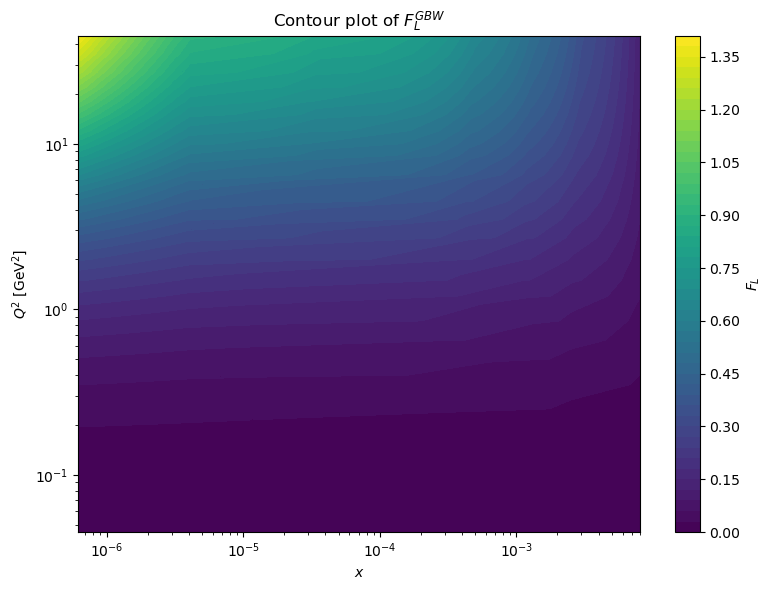

In [99]:
x_grid, Q2_grid = np.meshgrid(x_DIS, Q2_DIS)

plt.figure(figsize=(8, 6))

contour = plt.contourf(
    x_grid,
    Q2_grid,
    FLgrid,   
    levels=50,
    cmap='viridis'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$x$')
plt.ylabel(r'$Q^2$ [GeV$^2$]')
plt.title(r'Contour plot of $F_L^{GBW}$')

plt.colorbar(contour, label=r'$F_L$')

plt.tight_layout()
plt.savefig("FL_contour GBW.pdf", format="pdf")
plt.show()

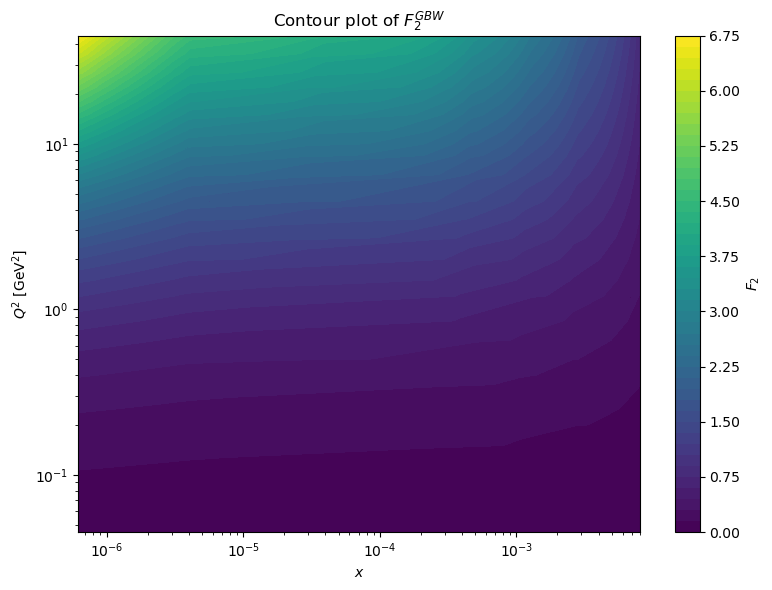

In [100]:
x_grid, Q2_grid = np.meshgrid(x_DIS, Q2_DIS)

plt.figure(figsize=(8, 6))

contour = plt.contourf(
    x_grid,
    Q2_grid,
    F2grid,   
    levels=50,
    cmap='viridis'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$x$')
plt.ylabel(r'$Q^2$ [GeV$^2$]')
plt.title(r'Contour plot of $F_2^{GBW}$')

plt.colorbar(contour, label=r'$F_2$')

plt.tight_layout()
plt.savefig("F2_contour GBW.pdf", format="pdf")
plt.show()

In [ ]:
print(rel_err_sigma_r_DIS[:10])

In [101]:
theory = compute_SigmaRDP_points()
data   = sigma_r_DIS

abs_err = data * rel_err_sigma_r_DIS / 100

chi2_points = ((theory - data)/abs_err)**2

chi2_total = np.sum(chi2_points)

print("N points =", len(data))
print("chi2 =", chi2_total)
print("chi2/N =", chi2_total/len(data))

N points = 271
chi2 = 987.6769109672863
chi2/N = 3.6445642471117576
